**Run note:** Execute cells top-to-bottom. This is **Phase 2b** — loads the Phase 1 checkpoint from notebook 09 with the **identical architecture**, then fine-tunes with lower learning rates and R-Drop regularization. Attach notebook 09 output as a Kaggle input.

# 09b — AUROC Optimization · Phase 2b: Continued Fine-Tuning with Lower LR

Continues from notebook 09 (Phase 1, AUROC 0.7306). Loads the **exact same architecture** from NB-09's checkpoint, then fine-tunes with lower learning rates to squeeze out more AUROC.

| Technique | Detail |
|-----------|--------|
| **Same architecture** | Identical `HatefulMemeClassifier` from NB-09 (3+3 unfrozen layers, 4-head cross-attention, 512→1024→256→128→2) |
| **Lower LR schedule** | Encoder: `1e-6` (halved from 3e-6), Head: `5e-5` (quartered from 2e-4) |
| **Cosine warmup** | 10% warmup, gentle cosine decay |
| **R-Drop regularization** | KL-divergence between two forward passes for consistency |
| **EMA + Focal loss + label smoothing** | Carried over from Phase 1 |

## Checkpoint flow
```
NB-08  →  cross_attention_best.pt          (NB-09 warm-start source)
NB-09  →  cross_attention_phase2_best.pt   (AUROC 0.7306, loaded here)
NB-09b →  cross_attention_phase2b_best.pt  (target: > 0.7306)
```

In [ ]:
import os
import json
import math
import random
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from torchvision import transforms
from transformers import CLIPModel, CLIPProcessor

ON_KAGGLE = Path('/kaggle/input').is_dir()
JSONL_CANDIDATES = {
    'train': ['train.jsonl'],
    'dev': ['dev.jsonl', 'dev_seen.jsonl', 'dev_unseen.jsonl'],
    'test': ['test.jsonl', 'test_seen.jsonl', 'test_unseen.jsonl'],
}
IMAGE_DIR_CANDIDATES = ('img', 'images')

def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)

def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)

def _looks_like_dataset_root(path: Path) -> bool:
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES['train'])

def detect_data_dir():
    for env_name in ('KAGGLE_DATA_DIR', 'META_HATEFUL_MEME_DATA_DIR'):
        env_dir = os.environ.get(env_name, '').strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f'env:{env_name}'
    kaggle_input = Path('/kaggle/input')
    default_candidate = kaggle_input / 'meta-hateful-meme-detection' / 'data'
    if _looks_like_dataset_root(default_candidate):
        return default_candidate, 'default:/kaggle/input/meta-hateful-meme-detection/data'
    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob('train.jsonl')):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f'auto:{candidate}'
        for candidate in sorted(kaggle_input.rglob('*')):
            if candidate.is_dir() and _looks_like_dataset_root(candidate):
                return candidate, f'auto:{candidate}'
    for candidate in (Path.cwd() / 'data', Path.cwd().parent / 'data', Path.cwd(), Path.cwd().parent):
        if _looks_like_dataset_root(candidate):
            return candidate, f'local:{candidate}'
    return None, 'not-found'

def resolve_split(base_dir, names):
    base_dir = Path(base_dir)
    for name in names:
        path = base_dir / name
        if path.is_file():
            return path
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None

DATA_DIR, data_source = detect_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError('Dataset not found. Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR.')

TRAIN_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES['train'])
DEV_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES['dev'])
if TRAIN_PATH is None or DEV_PATH is None:
    raise FileNotFoundError(f'Expected train/dev splits under {DATA_DIR}')

BASE_OUTPUT_DIR = Path('/kaggle/working') if ON_KAGGLE else Path.cwd() / 'outputs'
OUTPUT_DIR = Path('/kaggle/working') if ON_KAGGLE else Path.cwd() / 'outputs' / 'training_optimization'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
REFERENCE_BEST_AUROC = 0.7306   # NB-09 best

# ── Phase 2b config: SAME architecture as NB-09, lower LR + R-Drop ───────
CFG = {
    'clip_model': 'openai/clip-vit-base-patch32',
    'batch_size': 24 if torch.cuda.is_available() else 8,
    'epochs': 15,
    # Lower LRs than Phase 1 (was encoder_lr=3e-6, head_lr=2e-4)
    'encoder_lr': 1e-6,
    'head_lr': 5e-5,
    'weight_decay': 0.01,
    'warmup_ratio': 0.1,
    # MUST match NB-09 exactly for checkpoint compatibility
    'embed_dim': 512,
    'num_heads': 4,
    'dropout': 0.3,
    'max_text_len': 77,
    # Loss
    'focal_gamma': 2.0,
    'label_smoothing': 0.1,
    # Regularization
    'rdrop_alpha': 0.5,      # R-Drop KL regularization weight
    'grad_clip': 1.0,
    'patience': 6,
    'grad_accum': 2,
    'ema_decay': 0.999,
    # Augmentation
    'image_aug_prob': 0.35,
    'text_aug_prob': 0.25,
    # Unfreezing — MUST match NB-09 (3+3) for clean checkpoint load
    'unfreeze_vision_layers': 3,
    'unfreeze_text_layers': 3,
    # Checkpoint names to search for (NB-09 output)
    'phase1_checkpoint_names': [
        'cross_attention_phase2_best.pt',   # NB-09 output (AUROC 0.7306)
        'cross_attention_phase1_best.pt',   # legacy name
        'cross_attention_best.pt',          # NB-08 fallback
    ],
    'seed': 42,
}

# ── Pre-cache CLIP model locally (avoids repeated HF Hub downloads) ───────
_CLIP_CACHE = OUTPUT_DIR / 'hf_clip_cache' / 'clip-vit-base-patch32'
_CLIP_CACHE.mkdir(parents=True, exist_ok=True)

def _find_clip_source():
    """Search for existing CLIP cache: own cache → attached inputs → download."""
    if (_CLIP_CACHE / 'config.json').exists() and (_CLIP_CACHE / 'tokenizer_config.json').exists():
        return str(_CLIP_CACHE), 'own-cache'
    if ON_KAGGLE and Path('/kaggle/input').is_dir():
        for cfg_file in sorted(Path('/kaggle/input').rglob('clip-vit-base-patch32/config.json')):
            parent = cfg_file.parent
            if (parent / 'tokenizer_config.json').exists():
                return str(parent), f'attached:{parent}'
    return None, 'download-needed'

CLIP_MODEL_SOURCE, _clip_src = _find_clip_source()
if CLIP_MODEL_SOURCE is not None:
    print(f'Using cached CLIP from {CLIP_MODEL_SOURCE} ({_clip_src})', flush=True)
else:
    print('Downloading CLIP model + processor to local cache...', flush=True)
    t0 = time.perf_counter()
    _m = CLIPModel.from_pretrained(CFG['clip_model'])
    _m.save_pretrained(str(_CLIP_CACHE))
    del _m
    print(f'  Model cached in {time.perf_counter() - t0:.1f}s', flush=True)
    t1 = time.perf_counter()
    _p = CLIPProcessor.from_pretrained(CFG['clip_model'])
    _p.save_pretrained(str(_CLIP_CACHE))
    del _p
    print(f'  Processor cached in {time.perf_counter() - t1:.1f}s', flush=True)
    torch.cuda.empty_cache()
    CLIP_MODEL_SOURCE = str(_CLIP_CACHE)
    print(f'CLIP cached to {CLIP_MODEL_SOURCE}', flush=True)

def set_seeds(seed=CFG['seed']):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds()
print('DATA_DIR  :', DATA_DIR)
print('Source    :', data_source)
print('Output    :', OUTPUT_DIR)
print('Device    :', DEVICE)
print('Reference :', REFERENCE_BEST_AUROC, '(NB-09 Phase 1)')
print('Config    :', CFG)

DATA_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Source    : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output    : /kaggle/working
Device    : cuda
Reference : 0.7306 (NB-09 Phase 1)
Config    : {'clip_model': 'openai/clip-vit-base-patch32', 'batch_size': 24, 'epochs': 15, 'encoder_lr': 1e-06, 'head_lr': 5e-05, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'embed_dim': 512, 'num_heads': 4, 'dropout': 0.3, 'max_text_len': 77, 'focal_gamma': 2.0, 'label_smoothing': 0.1, 'rdrop_alpha': 0.5, 'grad_clip': 1.0, 'patience': 6, 'grad_accum': 2, 'ema_decay': 0.999, 'image_aug_prob': 0.35, 'text_aug_prob': 0.25, 'unfreeze_vision_layers': 3, 'unfreeze_text_layers': 3, 'phase1_checkpoint_names': ['cross_attention_phase2_best.pt', 'cross_attention_phase1_best.pt', 'cross_attention_best.pt'], 'seed': 42}


In [2]:
def load_jsonl(path):
    with open(path, encoding='utf-8') as handle:
        return pd.DataFrame([json.loads(line) for line in handle if line.strip()])

def clean_text(text):
    if not isinstance(text, str):
        return '[no text]'
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#(\w+)', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text or '[no text]'

def resolve_image_path(data_dir, image_ref):
    data_dir = Path(data_dir)
    image_ref = Path(str(image_ref))
    candidates = []
    if image_ref.is_absolute():
        candidates.append(image_ref)
    candidates.extend([data_dir / image_ref, data_dir.parent / image_ref])
    if image_ref.parts:
        if image_ref.parts[0] in {'img', 'images'} and len(image_ref.parts) > 1:
            stripped = Path(*image_ref.parts[1:])
            candidates.extend([data_dir / stripped, data_dir.parent / stripped])
        elif image_ref.parts[0] not in {'img', 'images'}:
            candidates.extend([
                data_dir / 'img' / image_ref,
                data_dir / 'images' / image_ref,
                data_dir.parent / 'img' / image_ref,
                data_dir.parent / 'images' / image_ref,
            ])
    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f'Could not find image {image_ref} relative to {data_dir}')

train_df = load_jsonl(TRAIN_PATH)
dev_df = load_jsonl(DEV_PATH)
for frame in (train_df, dev_df):
    frame['clean_text'] = frame['text'].apply(clean_text)

print(f'Train={len(train_df):,}, Dev={len(dev_df):,}')
print('Train label counts:', train_df['label'].value_counts().sort_index().to_dict())

Train=8,500, Dev=500
Train label counts: {0: 5450, 1: 3050}


In [ ]:
processor = CLIPProcessor.from_pretrained(CLIP_MODEL_SOURCE, use_fast=False, local_files_only=True)
train_image_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.2),
    transforms.RandomApply([transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15)], p=0.4),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.15),
])

def perturb_text(text):
    if random.random() > CFG['text_aug_prob']:
        return text
    tokens = text.split()
    if not tokens:
        return text
    mode = random.choice(['case', 'punct', 'swap', 'space'])
    if mode == 'case':
        idx = random.randrange(len(tokens))
        token = tokens[idx]
        tokens[idx] = token.upper() if token.lower() == token else token.lower()
        return ' '.join(tokens)
    if mode == 'punct':
        idx = random.randrange(len(tokens))
        tokens[idx] = tokens[idx] + random.choice(['!', '?', '.', '...'])
        return ' '.join(tokens)
    if mode == 'swap' and len(tokens) >= 2:
        idx = random.randrange(len(tokens) - 1)
        tokens[idx], tokens[idx + 1] = tokens[idx + 1], tokens[idx]
        return ' '.join(tokens)
    return ' '.join(list(text)) if mode == 'space' else text

def perturb_image(image):
    if random.random() > CFG['image_aug_prob']:
        return image
    mode = random.choice(['blur', 'noise', 'contrast', 'none'])
    if mode == 'blur':
        return image.filter(ImageFilter.GaussianBlur(radius=1.0))
    if mode == 'contrast':
        return ImageEnhance.Contrast(image).enhance(random.uniform(0.85, 1.15))
    if mode == 'noise':
        arr = np.array(image).astype(np.float32)
        arr += np.random.normal(0, 8, size=arr.shape)
        arr = np.clip(arr, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)
    return image

class OptimizedMemeDataset(Dataset):
    def __init__(self, df, data_dir, processor, training=False):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.processor = processor
        self.training = training

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = Image.open(resolve_image_path(self.data_dir, row['img'])).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), 128)

        text = row['clean_text']
        if self.training:
            image = train_image_transform(image)
            image = perturb_image(image)
            text = perturb_text(text)

        encoded = self.processor(
            text=[text],
            images=image,
            return_tensors='pt',
            padding='max_length',
            truncation=True,
            max_length=CFG['max_text_len']
        )
        return {
            'pixel_values': encoded['pixel_values'].squeeze(0),
            'input_ids': encoded['input_ids'].squeeze(0),
            'attention_mask': encoded['attention_mask'].squeeze(0),
            'label': torch.tensor(int(row['label']), dtype=torch.long)
        }

train_ds = OptimizedMemeDataset(train_df, DATA_DIR, processor, training=True)
dev_ds   = OptimizedMemeDataset(dev_df,   DATA_DIR, processor, training=False)

labels = train_df['label'].values
n_pos = int((labels == 1).sum())
n_neg = int((labels == 0).sum())
w_pos = len(labels) / (2.0 * n_pos)
w_neg = len(labels) / (2.0 * n_neg)
sample_weights = [w_neg if lab == 0 else w_pos for lab in labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], sampler=sampler, num_workers=0, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=CFG['batch_size'] * 2, shuffle=False, num_workers=0, pin_memory=True)
print(f'Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)}')

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Train batches: 355 | Dev batches: 11


In [ ]:
# ── Helper (handles newer transformers returning BaseModelOutput) ──────────
def _ensure_tensor(out):
    if isinstance(out, torch.Tensor):
        return out
    if hasattr(out, 'pooler_output') and out.pooler_output is not None:
        return out.pooler_output
    if hasattr(out, 'last_hidden_state'):
        return out.last_hidden_state[:, 0]
    return out[0]


# ── Model — EXACT same architecture as NB-08 / NB-09 ─────────────────────
class CLIPEncoder(nn.Module):
    def __init__(self, model_name=None):
        super().__init__()
        model_name = model_name or CLIP_MODEL_SOURCE
        print(f'  Loading CLIP model: {model_name} ...', flush=True)
        self.clip = CLIPModel.from_pretrained(model_name, local_files_only=Path(str(model_name)).exists())
        print(f'  CLIP model loaded.', flush=True)
        for p in self.clip.parameters():
            p.requires_grad_(False)

    def forward(self, pixel_values, input_ids, attention_mask):
        i = F.normalize(_ensure_tensor(
            self.clip.get_image_features(pixel_values=pixel_values)), dim=-1)
        t = F.normalize(_ensure_tensor(
            self.clip.get_text_features(input_ids=input_ids, attention_mask=attention_mask)), dim=-1)
        return i, t


class CrossAttentionFusion(nn.Module):
    def __init__(self, d=512, heads=4, drop=0.1):
        super().__init__()
        self.i2t = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.t2i = nn.MultiheadAttention(d, heads, dropout=drop, batch_first=True)
        self.ni  = nn.LayerNorm(d)
        self.nt  = nn.LayerNorm(d)

    def forward(self, i, t):
        is_ = i.unsqueeze(1); ts = t.unsqueeze(1)
        ic, ia = self.i2t(is_, ts, ts)
        tc, ta = self.t2i(ts, is_, is_)
        return torch.cat([self.ni(i + ic.squeeze(1)), self.nt(t + tc.squeeze(1))], dim=-1), ia, ta


class ClassificationHead(nn.Module):
    def __init__(self, d=1024, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 256), nn.GELU(), nn.Dropout(drop),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(drop),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)


class HatefulMemeClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = CLIPEncoder()
        self.fusion  = CrossAttentionFusion(CFG['embed_dim'], CFG['num_heads'], CFG['dropout'])
        self.head    = ClassificationHead(CFG['embed_dim'] * 2, CFG['dropout'])

    def forward(self, pixel_values, input_ids, attention_mask):
        i, t = self.encoder(pixel_values, input_ids, attention_mask)
        fused, ia, ta = self.fusion(i, t)
        return self.head(fused), ia, ta


# ── Partial CLIP Unfreezing (must match NB-09: 3+3) ──────────────────────
def unfreeze_last_layers(model, vision_n=3, text_n=3):
    clip = model.encoder.clip
    for layer in clip.vision_model.encoder.layers[-vision_n:]:
        for p in layer.parameters():
            p.requires_grad_(True)
    for layer in clip.text_model.encoder.layers[-text_n:]:
        for p in layer.parameters():
            p.requires_grad_(True)
    for module in [
        clip.vision_model.post_layernorm,
        clip.text_model.final_layer_norm,
        clip.visual_projection,
        clip.text_projection,
    ]:
        for p in module.parameters():
            p.requires_grad_(True)
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable: {trainable:,} / {total:,}  ({100 * trainable / total:.1f}%)")
    print(f"  Unfrozen: last {vision_n} vision blocks + last {text_n} text blocks + projections")


# ── Checkpoint auto-discovery ─────────────────────────────────────────────
def find_checkpoint(name):
    search_roots = []
    if ON_KAGGLE and Path('/kaggle/input').exists():
        search_roots.append(Path('/kaggle/input'))
    search_roots.extend([BASE_OUTPUT_DIR, OUTPUT_DIR, Path.cwd() / 'outputs'])
    candidates = []
    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        print(f'  Searching {root} for {name} ...', flush=True)
        for match in root.rglob(name):
            resolved = match.resolve()
            if resolved not in seen:
                seen.add(resolved)
                candidates.append(match)
    if not candidates:
        return None
    candidates.sort(key=lambda p: (0 if '/kaggle/input/' in str(p).replace('\\', '/').lower() else 1, len(str(p))))
    print(f'Checkpoint candidates for {name}:')
    for c in candidates[:5]:
        print(f'  - {c}')
    return candidates[0]


def find_phase1_checkpoint():
    for name in CFG['phase1_checkpoint_names']:
        ckpt = find_checkpoint(name)
        if ckpt is not None:
            return ckpt
    return None


# ── Build model + load Phase 1 checkpoint ─────────────────────────────────
print('Building HatefulMemeClassifier ...', flush=True)
model = HatefulMemeClassifier()
print('Unfreezing layers ...', flush=True)
unfreeze_last_layers(model, CFG['unfreeze_vision_layers'], CFG['unfreeze_text_layers'])

print('Searching for Phase 1 checkpoint ...', flush=True)
phase1_ckpt = find_phase1_checkpoint()
if phase1_ckpt is not None:
    print(f'Loading checkpoint: {phase1_ckpt} ...', flush=True)
    state = torch.load(phase1_ckpt, map_location='cpu', weights_only=False)
    model.load_state_dict(state, strict=True)
    print(f'Loaded Phase 1 checkpoint (strict=True): {phase1_ckpt}', flush=True)
else:
    print('WARNING: Phase 1 checkpoint not found — training from scratch.', flush=True)
    print('  Searched for:', CFG['phase1_checkpoint_names'])
    print('  Ensure you attach NB-09 output as a Kaggle dataset input.')

print('Moving model to device ...', flush=True)
model = model.to(DEVICE)
print(f'Model on {DEVICE} — ready.', flush=True)

Building HatefulMemeClassifier ...
  Loading CLIP model: openai/clip-vit-base-patch32 ...


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  CLIP model loaded.
Unfreezing layers ...
Trainable: 33,777,538 / 153,676,163  (22.0%)
  Unfrozen: last 3 vision blocks + last 3 text blocks + projections
Searching for Phase 1 checkpoint ...
  Searching /kaggle/input for cross_attention_phase2_best.pt ...


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

  Searching /kaggle/working for cross_attention_phase2_best.pt ...
  Searching /kaggle/working for cross_attention_phase2_best.pt ...
Checkpoint candidates for cross_attention_phase2_best.pt:
  - /kaggle/input/notebooks/muddybuddy/09-auroc-optimization/cross_attention_phase2_best.pt
Loading checkpoint: /kaggle/input/notebooks/muddybuddy/09-auroc-optimization/cross_attention_phase2_best.pt ...
Loaded Phase 1 checkpoint (strict=True): /kaggle/input/notebooks/muddybuddy/09-auroc-optimization/cross_attention_phase2_best.pt
Moving model to device ...
Model on cuda — ready.


In [5]:
# ── Focal Loss + Label Smoothing (same as NB-09) ─────────────────────────
class FocalLossWithSmoothing(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.gamma     = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        n = logits.size(1)
        ce_hard      = F.cross_entropy(logits, targets, reduction='none')
        focal_weight = (1.0 - torch.exp(-ce_hard)) ** self.gamma
        log_probs    = F.log_softmax(logits, dim=-1)
        smooth_tgts  = torch.full_like(log_probs, self.smoothing / (n - 1))
        smooth_tgts.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        smooth_ce    = -(smooth_tgts * log_probs).sum(dim=-1)
        return (focal_weight * smooth_ce).mean()


# ── EMA ───────────────────────────────────────────────────────────────────
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay  = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters() if p.requires_grad}
        self.backup = {}

    @torch.no_grad()
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n].mul_(self.decay).add_(p.data, alpha=1 - self.decay)

    def apply(self, model):
        self.backup = {}
        for n, p in model.named_parameters():
            if n in self.shadow:
                self.backup[n] = p.data.clone()
                p.data.copy_(self.shadow[n])

    def restore(self, model):
        for n, p in model.named_parameters():
            if n in self.backup:
                p.data.copy_(self.backup[n])


# ── Discriminative-LR Optimizer ───────────────────────────────────────────
def make_optimizer(model):
    encoder_params, head_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if 'encoder.clip' in name:
            encoder_params.append(param)
        else:
            head_params.append(param)
    print(f"Optimizer: encoder {sum(p.numel() for p in encoder_params):,} params @ lr={CFG['encoder_lr']}")
    print(f"           head    {sum(p.numel() for p in head_params):,} params @ lr={CFG['head_lr']}")
    return torch.optim.AdamW([
        {'params': encoder_params, 'lr': CFG['encoder_lr']},
        {'params': head_params,    'lr': CFG['head_lr']},
    ], weight_decay=CFG['weight_decay'])


def make_scheduler(optimizer, total_steps):
    warmup_steps = int(total_steps * CFG['warmup_ratio'])
    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


# ── R-Drop: KL regularization between two forward passes ─────────────────
def rdrop_kl_loss(logits1, logits2):
    """Symmetric KL between two stochastic forward passes."""
    p = F.log_softmax(logits1, dim=-1)
    q = F.softmax(logits2, dim=-1)
    kl1 = F.kl_div(p, q, reduction='batchmean')
    kl2 = F.kl_div(F.log_softmax(logits2, dim=-1), F.softmax(logits1, dim=-1), reduction='batchmean')
    return (kl1 + kl2) / 2


# ── Evaluation ────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs, all_preds, all_labels = [], [], []
    for batch in loader:
        pv = batch['pixel_values'].to(DEVICE)
        ids = batch['input_ids'].to(DEVICE)
        am = batch['attention_mask'].to(DEVICE)
        logits, _, _ = model(pv, ids, am)
        probs = torch.softmax(logits.float(), dim=-1)[:, 1]
        all_probs.extend(probs.cpu().numpy().tolist())
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy().tolist())
        all_labels.extend(batch['label'].numpy().tolist())
    return {
        'auroc': roc_auc_score(all_labels, all_probs),
        'f1': f1_score(all_labels, all_preds, pos_label=1),
        'accuracy': accuracy_score(all_labels, all_preds),
    }


# ── Training loop ────────────────────────────────────────────────────────
def train_phase2b():
    set_seeds()
    optimizer = make_optimizer(model)
    accum     = CFG['grad_accum']
    total_opt_steps = (len(train_loader) // accum) * CFG['epochs']
    scheduler = make_scheduler(optimizer, total_opt_steps)
    scaler    = GradScaler(enabled=(DEVICE == 'cuda'))
    criterion = FocalLossWithSmoothing(gamma=CFG['focal_gamma'], smoothing=CFG['label_smoothing']).to(DEVICE)
    ema       = EMA(model, decay=CFG['ema_decay'])

    history   = {'train_loss': [], 'train_cls_loss': [], 'train_rdrop_loss': [],
                 'val_auroc': [], 'val_f1': [], 'val_accuracy': []}
    best_auroc   = -1.0
    best_path    = OUTPUT_DIR / 'cross_attention_phase2b_best.pt'
    patience_left = CFG['patience']

    for epoch in range(1, CFG['epochs'] + 1):
        model.train()
        epoch_loss = epoch_cls = epoch_rd = 0.0
        start = time.time()
        optimizer.zero_grad(set_to_none=True)

        for step, batch in enumerate(train_loader):
            pv     = batch['pixel_values'].to(DEVICE)
            ids    = batch['input_ids'].to(DEVICE)
            am     = batch['attention_mask'].to(DEVICE)
            labels = batch['label'].to(DEVICE)

            with autocast(enabled=(DEVICE == 'cuda')):
                logits1, _, _ = model(pv, ids, am)
                cls_loss = criterion(logits1, labels)

                # R-Drop: second forward pass with different dropout masks
                rd_loss = torch.tensor(0.0, device=DEVICE)
                if CFG['rdrop_alpha'] > 0:
                    logits2, _, _ = model(pv, ids, am)
                    rd_loss = rdrop_kl_loss(logits1, logits2)
                    cls_loss2 = criterion(logits2, labels)
                    cls_loss = (cls_loss + cls_loss2) / 2

                loss = cls_loss + CFG['rdrop_alpha'] * rd_loss
                loss = loss / accum

            scaler.scale(loss).backward()
            epoch_loss += loss.item() * accum
            epoch_cls  += cls_loss.item()
            epoch_rd   += rd_loss.item()

            if (step + 1) % accum == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                ema.update(model)

        ema.apply(model)
        metrics = evaluate(model, dev_loader)
        ema.restore(model)

        n = max(1, len(train_loader))
        avg_loss = epoch_loss / n
        avg_cls  = epoch_cls  / n
        avg_rd   = epoch_rd   / n
        history['train_loss'].append(avg_loss)
        history['train_cls_loss'].append(avg_cls)
        history['train_rdrop_loss'].append(avg_rd)
        history['val_auroc'].append(metrics['auroc'])
        history['val_f1'].append(metrics['f1'])
        history['val_accuracy'].append(metrics['accuracy'])

        elapsed = time.time() - start
        print(f"Epoch {epoch:02d}/{CFG['epochs']} | loss={avg_loss:.4f} | cls={avg_cls:.4f} "
              f"| rd={avg_rd:.4f} | AUROC={metrics['auroc']:.4f} | F1={metrics['f1']:.4f} "
              f"| ACC={metrics['accuracy']:.4f} | {elapsed:.0f}s")

        if metrics['auroc'] > best_auroc:
            best_auroc = metrics['auroc']
            patience_left = CFG['patience']
            ema.apply(model)
            torch.save(model.state_dict(), best_path)
            ema.restore(model)
            print(f'  => new best AUROC {best_auroc:.4f}  (saved)')
        else:
            patience_left -= 1
            print(f'  => no improvement, patience left: {patience_left}')
            if patience_left <= 0:
                print('  Early stop.')
                break

    with open(OUTPUT_DIR / 'phase2b_history.json', 'w', encoding='utf-8') as f:
        json.dump(history, f)
    return history, best_auroc, best_path

print('Phase 2b training utilities ready.')

Phase 2b training utilities ready.


In [6]:
history, best_auroc, best_path = train_phase2b()
print()
print('=' * 55)
print('Reference NB-09 AUROC :', REFERENCE_BEST_AUROC)
print('Phase 2b best AUROC   :', round(best_auroc, 4))
print('Delta                 :', f'{round(best_auroc - REFERENCE_BEST_AUROC, 4):+.4f}')
print('Final checkpoint      :', best_path)
print('=' * 55)
print()
if best_auroc > REFERENCE_BEST_AUROC:
    print('Phase 2b improved over NB-09. Proceed to notebook 10 with cross_attention_phase2b_best.pt.')
else:
    print('Phase 2b did not surpass NB-09. Use NB-09 checkpoint or try ensemble (next cell).')

Optimizer: encoder 31,378,688 params @ lr=1e-06
           head    2,398,850 params @ lr=5e-05


/tmp/ipykernel_24/3499111583.py:111: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=(DEVICE == 'cuda'))
/tmp/ipykernel_24/3499111583.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


Epoch 01/15 | loss=0.0451 | cls=0.0241 | rd=0.0421 | AUROC=0.7253 | F1=0.5130 | ACC=0.6240 | 165s
  => new best AUROC 0.7253  (saved)


/tmp/ipykernel_24/3499111583.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


Epoch 02/15 | loss=0.0396 | cls=0.0208 | rd=0.0377 | AUROC=0.7255 | F1=0.5078 | ACC=0.6200 | 155s
  => new best AUROC 0.7255  (saved)


...

Epoch 06/15 | loss=0.0261 | cls=0.0133 | rd=0.0256 | AUROC=0.7226 | F1=0.5143 | ACC=0.6260 | 144s
  => no improvement, patience left: 2


/tmp/ipykernel_24/3499111583.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


Epoch 07/15 | loss=0.0251 | cls=0.0136 | rd=0.0230 | AUROC=0.7214 | F1=0.5091 | ACC=0.6220 | 143s
  => no improvement, patience left: 1


/tmp/ipykernel_24/3499111583.py:133: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE == 'cuda')):


Epoch 08/15 | loss=0.0234 | cls=0.0121 | rd=0.0225 | AUROC=0.7199 | F1=0.5052 | ACC=0.6200 | 145s
  => no improvement, patience left: 0
  Early stop.

Reference NB-09 AUROC : 0.7306
Phase 2b best AUROC   : 0.7255
Delta                 : -0.0051
Final checkpoint      : /kaggle/working/cross_attention_phase2b_best.pt

Phase 2b did not surpass NB-09. Use NB-09 checkpoint or try ensemble (next cell).


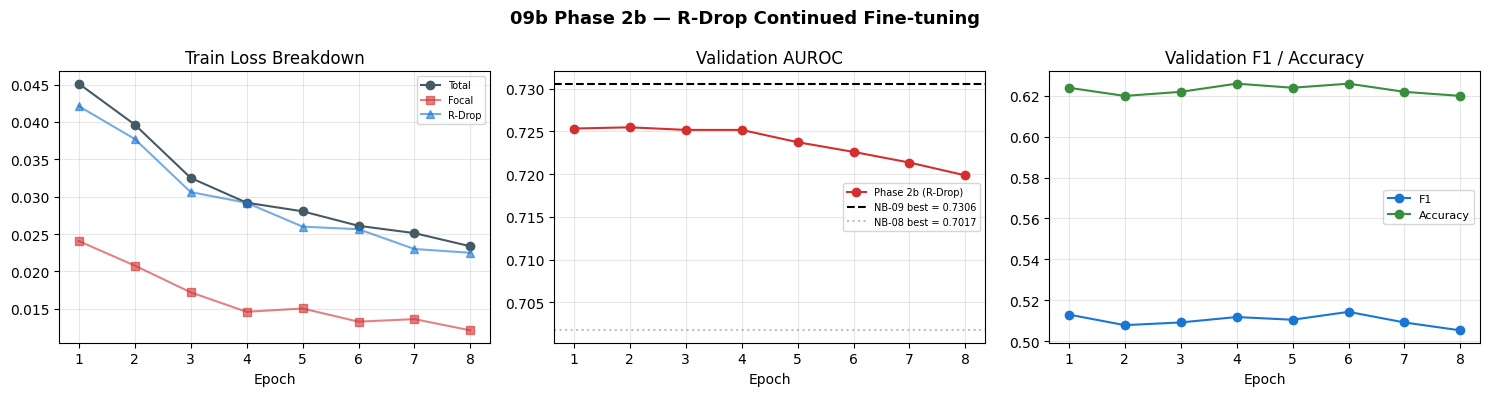

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs, history['train_loss'], marker='o', color='#455A64', label='Total')
axes[0].plot(epochs, history['train_cls_loss'], marker='s', color='#D32F2F', alpha=0.6, label='Focal')
axes[0].plot(epochs, history['train_rdrop_loss'], marker='^', color='#1976D2', alpha=0.6, label='R-Drop')
axes[0].set_title('Train Loss Breakdown')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_auroc'], marker='o', color='#D32F2F', label='Phase 2b (R-Drop)')
axes[1].axhline(REFERENCE_BEST_AUROC, ls='--', color='black', label=f'NB-09 best = {REFERENCE_BEST_AUROC}')
axes[1].axhline(0.7017, ls=':', color='gray', alpha=0.5, label='NB-08 best = 0.7017')
axes[1].set_title('Validation AUROC')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, history['val_f1'], marker='o', color='#1976D2', label='F1')
axes[2].plot(epochs, history['val_accuracy'], marker='o', color='#388E3C', label='Accuracy')
axes[2].set_title('Validation F1 / Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.suptitle('09b Phase 2b — R-Drop Continued Fine-tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '09b_phase2b_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Threshold Optimization

Search for the optimal classification threshold that maximises F1 on the dev set.

In [8]:
# ── Load best Phase 2b checkpoint & optimize threshold ────────────────────
from sklearn.metrics import roc_curve

@torch.no_grad()
def get_probs_and_labels(mdl, loader):
    mdl.eval()
    all_probs, all_labels = [], []
    for batch in loader:
        pv  = batch['pixel_values'].to(DEVICE)
        ids = batch['input_ids'].to(DEVICE)
        am  = batch['attention_mask'].to(DEVICE)
        logits, _, _ = mdl(pv, ids, am)
        probs = torch.softmax(logits.float(), dim=-1)[:, 1]
        all_probs.extend(probs.cpu().numpy().tolist())
        all_labels.extend(batch['label'].numpy().tolist())
    return np.array(all_probs), np.array(all_labels)

# Load best phase2b checkpoint
best_ckpt = OUTPUT_DIR / 'cross_attention_phase2b_best.pt'
if best_ckpt.exists():
    state = torch.load(best_ckpt, map_location='cpu')
    model.load_state_dict(state, strict=True)
    model = model.to(DEVICE)
    print(f'Loaded best Phase 2b checkpoint: {best_ckpt}')

student_probs, labels = get_probs_and_labels(model, dev_loader)
student_auroc = roc_auc_score(labels, student_probs)
print(f'Phase 2b AUROC: {student_auroc:.4f}')

# ── Optimal threshold ────────────────────────────────────────────────────
# Youden's J statistic
fpr, tpr, thresholds = roc_curve(labels, student_probs)
j_scores = tpr - fpr
best_thresh_j = thresholds[np.argmax(j_scores)]

# Sweep for max F1
best_f1, best_f1_thresh = 0, 0.5
for t in np.arange(0.30, 0.70, 0.01):
    preds = (student_probs >= t).astype(int)
    f = f1_score(labels, preds, pos_label=1)
    if f > best_f1:
        best_f1, best_f1_thresh = f, t

final_preds = (student_probs >= best_f1_thresh).astype(int)
final_f1  = f1_score(labels, final_preds, pos_label=1)
final_acc = accuracy_score(labels, final_preds)

print(f'\nOptimal threshold (Youden J): {best_thresh_j:.3f}')
print(f'Optimal threshold (max F1):   {best_f1_thresh:.3f}')
print(f'F1  @ optimal thresh: {final_f1:.4f}')
print(f'Acc @ optimal thresh: {final_acc:.4f}')
print()

print('=' * 60)
print(f'NB-08 baseline AUROC       : 0.7017')
print(f'NB-09 Phase 1 AUROC        : {REFERENCE_BEST_AUROC}')
print(f'NB-09b Phase 2b AUROC      : {student_auroc:.4f}')
print(f'NB-09b Phase 2b F1         : {final_f1:.4f}  (thresh={best_f1_thresh:.2f})')
print('=' * 60)

if student_auroc > REFERENCE_BEST_AUROC:
    print(f'\nPhase 2b improved! Use cross_attention_phase2b_best.pt for notebook 10.')
else:
    print(f'\nPhase 2b did not surpass NB-09. Use cross_attention_phase2_best.pt for notebook 10.')

Loaded best Phase 2b checkpoint: /kaggle/working/cross_attention_phase2b_best.pt
Phase 2b AUROC: 0.7255

Optimal threshold (Youden J): 0.194
Optimal threshold (max F1):   0.300
F1  @ optimal thresh: 0.5902
Acc @ optimal thresh: 0.6500

NB-08 baseline AUROC       : 0.7017
NB-09 Phase 1 AUROC        : 0.7306
NB-09b Phase 2b AUROC      : 0.7255
NB-09b Phase 2b F1         : 0.5902  (thresh=0.30)

Phase 2b did not surpass NB-09. Use cross_attention_phase2_best.pt for notebook 10.
